Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Settings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

Load data

In [3]:
df = pd.read_csv("../data/civ5_leaders.csv")
print(f"Dataset: {df.shape[0]} leaders x {df.shape[1]} variables")
df.head()

Dataset: 43 leaders x 65 variables


,leader_name,leader_type,VictoryCompetitiveness,WonderCompetitiveness,MinorCivCompetitiveness,Boldness,DiploBalance,WarmongerHate,DenounceWillingness,DoFWillingness,Loyalty,Neediness,Forgiveness,Chattiness,Meanness,MAJOR_WAR,MAJOR_HOSTILE,MAJOR_DECEPTIVE,MAJOR_GUARDED,MAJOR_AFRAID,MAJOR_FRIENDLY,MAJOR_NEUTRAL,MINOR_IGNORE,MINOR_FRIENDLY,MINOR_PROTECTIVE,MINOR_CONQUEST,MINOR_BULLY,OFFENSE,DEFENSE,CITY_DEFENSE,MILITARY_TRAINING,RECON,RANGED,MOBILE,NAVAL,NAVAL_RECON,NAVAL_GROWTH,NAVAL_TILE_IMPROVEMENT,AIR,EXPANSION,GROWTH,TILE_IMPROVEMENT,INFRASTRUCTURE,PRODUCTION,GOLD,SCIENCE,CULTURE,HAPPINESS,GREAT_PEOPLE,WONDER,RELIGION,DIPLOMACY,SPACESHIP,WATER_CONNECTION,NUKE,USE_NUKE,ESPIONAGE,ANTIAIR,AIR_CARRIER,I_LAND_TRADE_ROUTE,I_SEA_TRADE_ROUTE,ARCHAEOLOGY,I_TRADE_ORIGIN,I_TRADE_DESTINATION,AIRLIFT
0,AhmadalMansur,LEADER_AHMAD_ALMANSUR,5,4,5,4,5,5,5,6,6,6,5,6,5,5,4,5,6,5,8,5,4,6,6,4,4.0,5,7,6,5,3,5,7,5,5,5,5,6,4,6,7,6,6,5,5,7,5,4,4,6,5,5,5,5,6.0,8.0,5.0,5.0,5,5,5,5,5,5
1,Alexander,LEADER_ALEXANDER,8,7,3,8,3,2,7,4,4,4,5,7,7,6,7,4,5,3,5,4,4,5,8,4,3.0,8,5,5,5,5,3,8,5,5,6,6,3,8,4,4,4,5,3,6,7,5,6,6,5,9,7,6,7,5.0,5.0,5.0,5.0,5,5,5,5,5,5
2,Ashurbanipal,LEADER_ASHURBANIPAL,5,5,3,6,5,4,6,5,5,4,4,3,5,8,6,4,5,3,5,5,4,4,3,7,5.0,7,3,5,8,4,6,6,5,5,5,5,5,6,5,5,5,6,5,7,5,5,5,5,4,4,7,5,6,7.0,5.0,5.0,5.0,5,5,5,5,5,5
3,Askia,LEADER_ASKIA,5,8,4,7,6,4,5,6,6,4,4,5,6,7,6,3,6,3,6,5,5,5,4,8,7.0,8,4,5,6,5,5,7,6,6,6,6,4,5,6,5,5,5,8,4,6,4,6,3,7,5,8,6,5,5.0,5.0,5.0,6.0,5,5,5,5,5,5
4,Attila,LEADER_ATTILA,7,3,3,8,4,3,6,3,4,3,4,5,8,8,8,8,3,3,3,5,5,4,3,7,8.0,8,4,3,6,6,7,8,4,4,4,4,5,7,4,5,4,6,7,3,5,5,6,5,5,5,5,4,5,8.0,4.0,5.0,6.0,5,5,5,5,5,5


Define feature groups

In [4]:
id_cols = ["leader_name", "leader_type"]

diplo_traits = [
    "VictoryCompetitiveness", "WonderCompetitiveness", "MinorCivCompetitiveness",
    "Boldness", "DiploBalance", "WarmongerHate", "DenounceWillingness",
    "DoFWillingness", "Loyalty", "Neediness", "Forgiveness", "Chattiness", "Meanness"
]

major_approaches = [
    "MAJOR_WAR", "MAJOR_HOSTILE", "MAJOR_DECEPTIVE", "MAJOR_GUARDED",
    "MAJOR_AFRAID", "MAJOR_FRIENDLY", "MAJOR_NEUTRAL"
]

minor_approaches = [
    "MINOR_IGNORE", "MINOR_FRIENDLY", "MINOR_PROTECTIVE",
    "MINOR_CONQUEST", "MINOR_BULLY"
]

flavors = [c for c in df.columns if c not in id_cols + diplo_traits + major_approaches + minor_approaches]

print(f"Diplomatic traits : {len(diplo_traits)}")
print(f"Major approaches  : {len(major_approaches)}")
print(f"Minor approaches  : {len(minor_approaches)}")
print(f"Flavors           : {len(flavors)}")

Diplomatic traits : 13
Major approaches  : 7
Minor approaches  : 5
Flavors           : 38


Diplomatic traits distribution

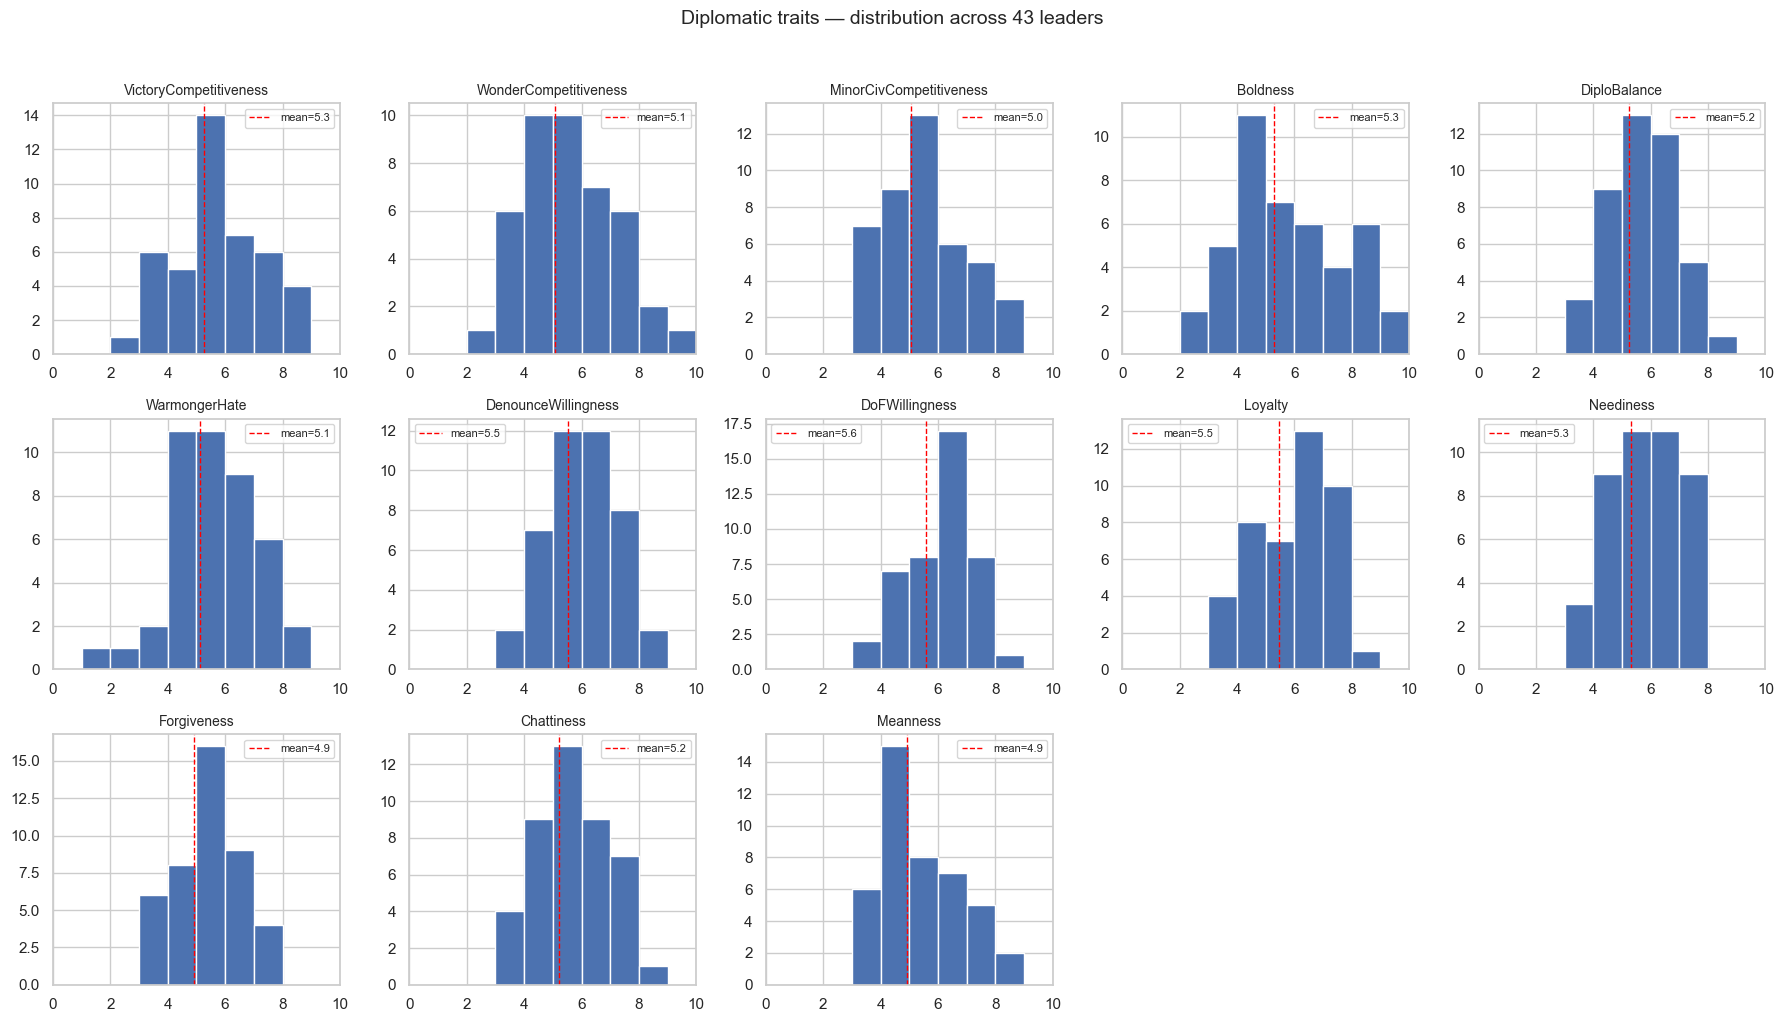

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(diplo_traits):
    axes[i].hist(df[col], bins=10, range=(0, 10), edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlim(0, 10)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label=f"mean={df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

for j in range(len(diplo_traits), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Diplomatic traits — distribution across 43 leaders", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Diplomatic traits summary statistics

In [6]:
summary = df[diplo_traits].describe().T[["mean", "std", "min", "max"]]
summary["range"] = summary["max"] - summary["min"]
summary = summary.sort_values("std", ascending=False)
print(summary.round(2))

                         mean   std  min  max  range
Boldness                 5.30  1.91  2.0  9.0    7.0
WonderCompetitiveness    5.09  1.60  2.0  9.0    7.0
VictoryCompetitiveness   5.26  1.56  2.0  8.0    6.0
WarmongerHate            5.12  1.50  1.0  8.0    7.0
MinorCivCompetitiveness  5.05  1.46  3.0  8.0    5.0
Meanness                 4.91  1.41  3.0  8.0    5.0
Loyalty                  5.47  1.35  3.0  8.0    5.0
Chattiness               5.21  1.28  3.0  8.0    5.0
DenounceWillingness      5.53  1.24  3.0  8.0    5.0
Neediness                5.33  1.23  3.0  7.0    4.0
DiploBalance             5.23  1.19  3.0  8.0    5.0
DoFWillingness           5.58  1.18  3.0  8.0    5.0
Forgiveness              4.93  1.16  3.0  7.0    4.0


Major approaches distribution

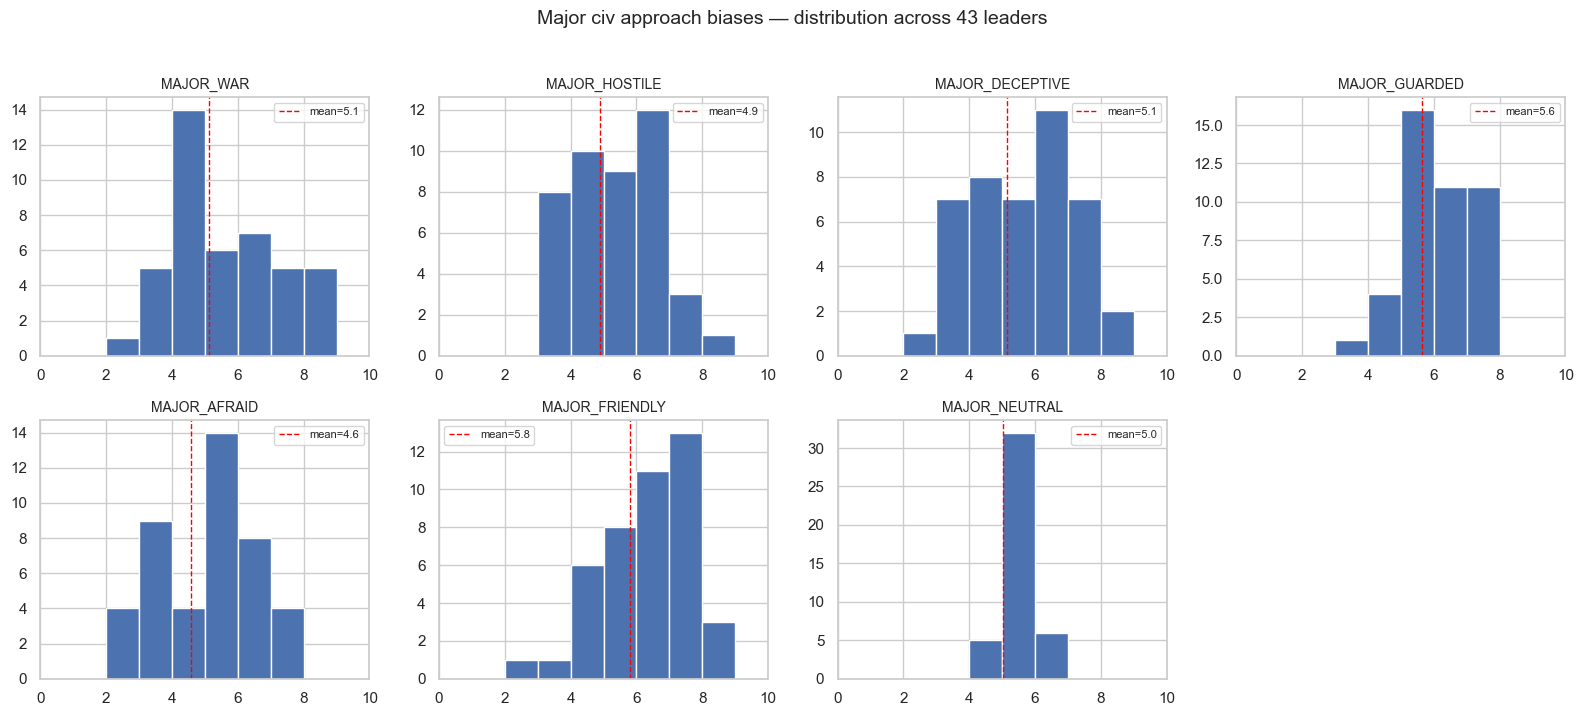

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(major_approaches):
    axes[i].hist(df[col], bins=10, range=(0, 10), edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlim(0, 10)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label=f"mean={df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

for j in range(len(major_approaches), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Major civ approach biases — distribution across 43 leaders", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Major approaches summary statistics

In [8]:
summary = df[major_approaches].describe().T[["mean", "std", "min", "max"]]
summary["range"] = summary["max"] - summary["min"]
summary = summary.sort_values("std", ascending=False)
print(summary.round(2))

                 mean   std  min  max  range
MAJOR_WAR        5.12  1.65  2.0  8.0    6.0
MAJOR_DECEPTIVE  5.14  1.55  2.0  8.0    6.0
MAJOR_AFRAID     4.58  1.48  2.0  7.0    5.0
MAJOR_FRIENDLY   5.81  1.38  2.0  8.0    6.0
MAJOR_HOSTILE    4.88  1.33  3.0  8.0    5.0
MAJOR_GUARDED    5.63  1.05  3.0  7.0    4.0
MAJOR_NEUTRAL    5.02  0.51  4.0  6.0    2.0


Minor approaches distribution

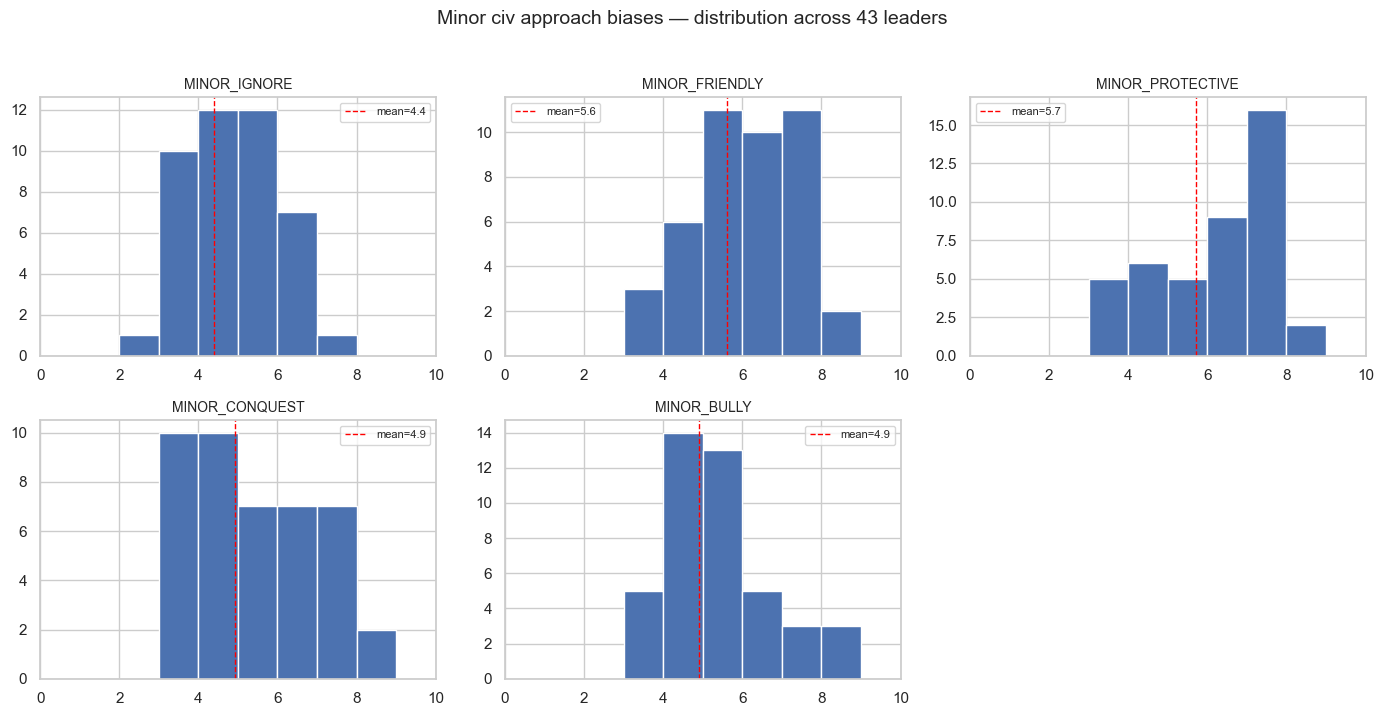

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(minor_approaches):
    axes[i].hist(df[col], bins=10, range=(0, 10), edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlim(0, 10)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label=f"mean={df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

for j in range(len(minor_approaches), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Minor civ approach biases — distribution across 43 leaders", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Minor approaches summary statistics + city-state bullies

In [10]:
summary = df[minor_approaches].describe().T[["mean", "std", "min", "max"]]
summary["range"] = summary["max"] - summary["min"]
summary = summary.sort_values("std", ascending=False)
print(summary.round(2))

for col in ["MINOR_CONQUEST", "MINOR_BULLY"]:
    print(f"\nTop 5 — {col}:")
    print(df[["leader_name", col]].sort_values(col, ascending=False).head(5).to_string(index=False))

                  mean   std  min  max  range
MINOR_CONQUEST    4.93  1.56  3.0  8.0    5.0
MINOR_PROTECTIVE  5.72  1.50  3.0  8.0    5.0
MINOR_BULLY       4.91  1.36  3.0  8.0    5.0
MINOR_FRIENDLY    5.60  1.33  3.0  8.0    5.0
MINOR_IGNORE      4.40  1.16  2.0  7.0    5.0

Top 5 — MINOR_CONQUEST:
 leader_name  MINOR_CONQUEST
       Askia               8
   Montezuma               8
    Napoleon               7
Ashurbanipal               7
      Attila               7

Top 5 — MINOR_BULLY:
leader_name  MINOR_BULLY
     Attila          8.0
  Montezuma          8.0
      Shaka          8.0
     Darius          7.0
      Askia          7.0


Flavors distribution

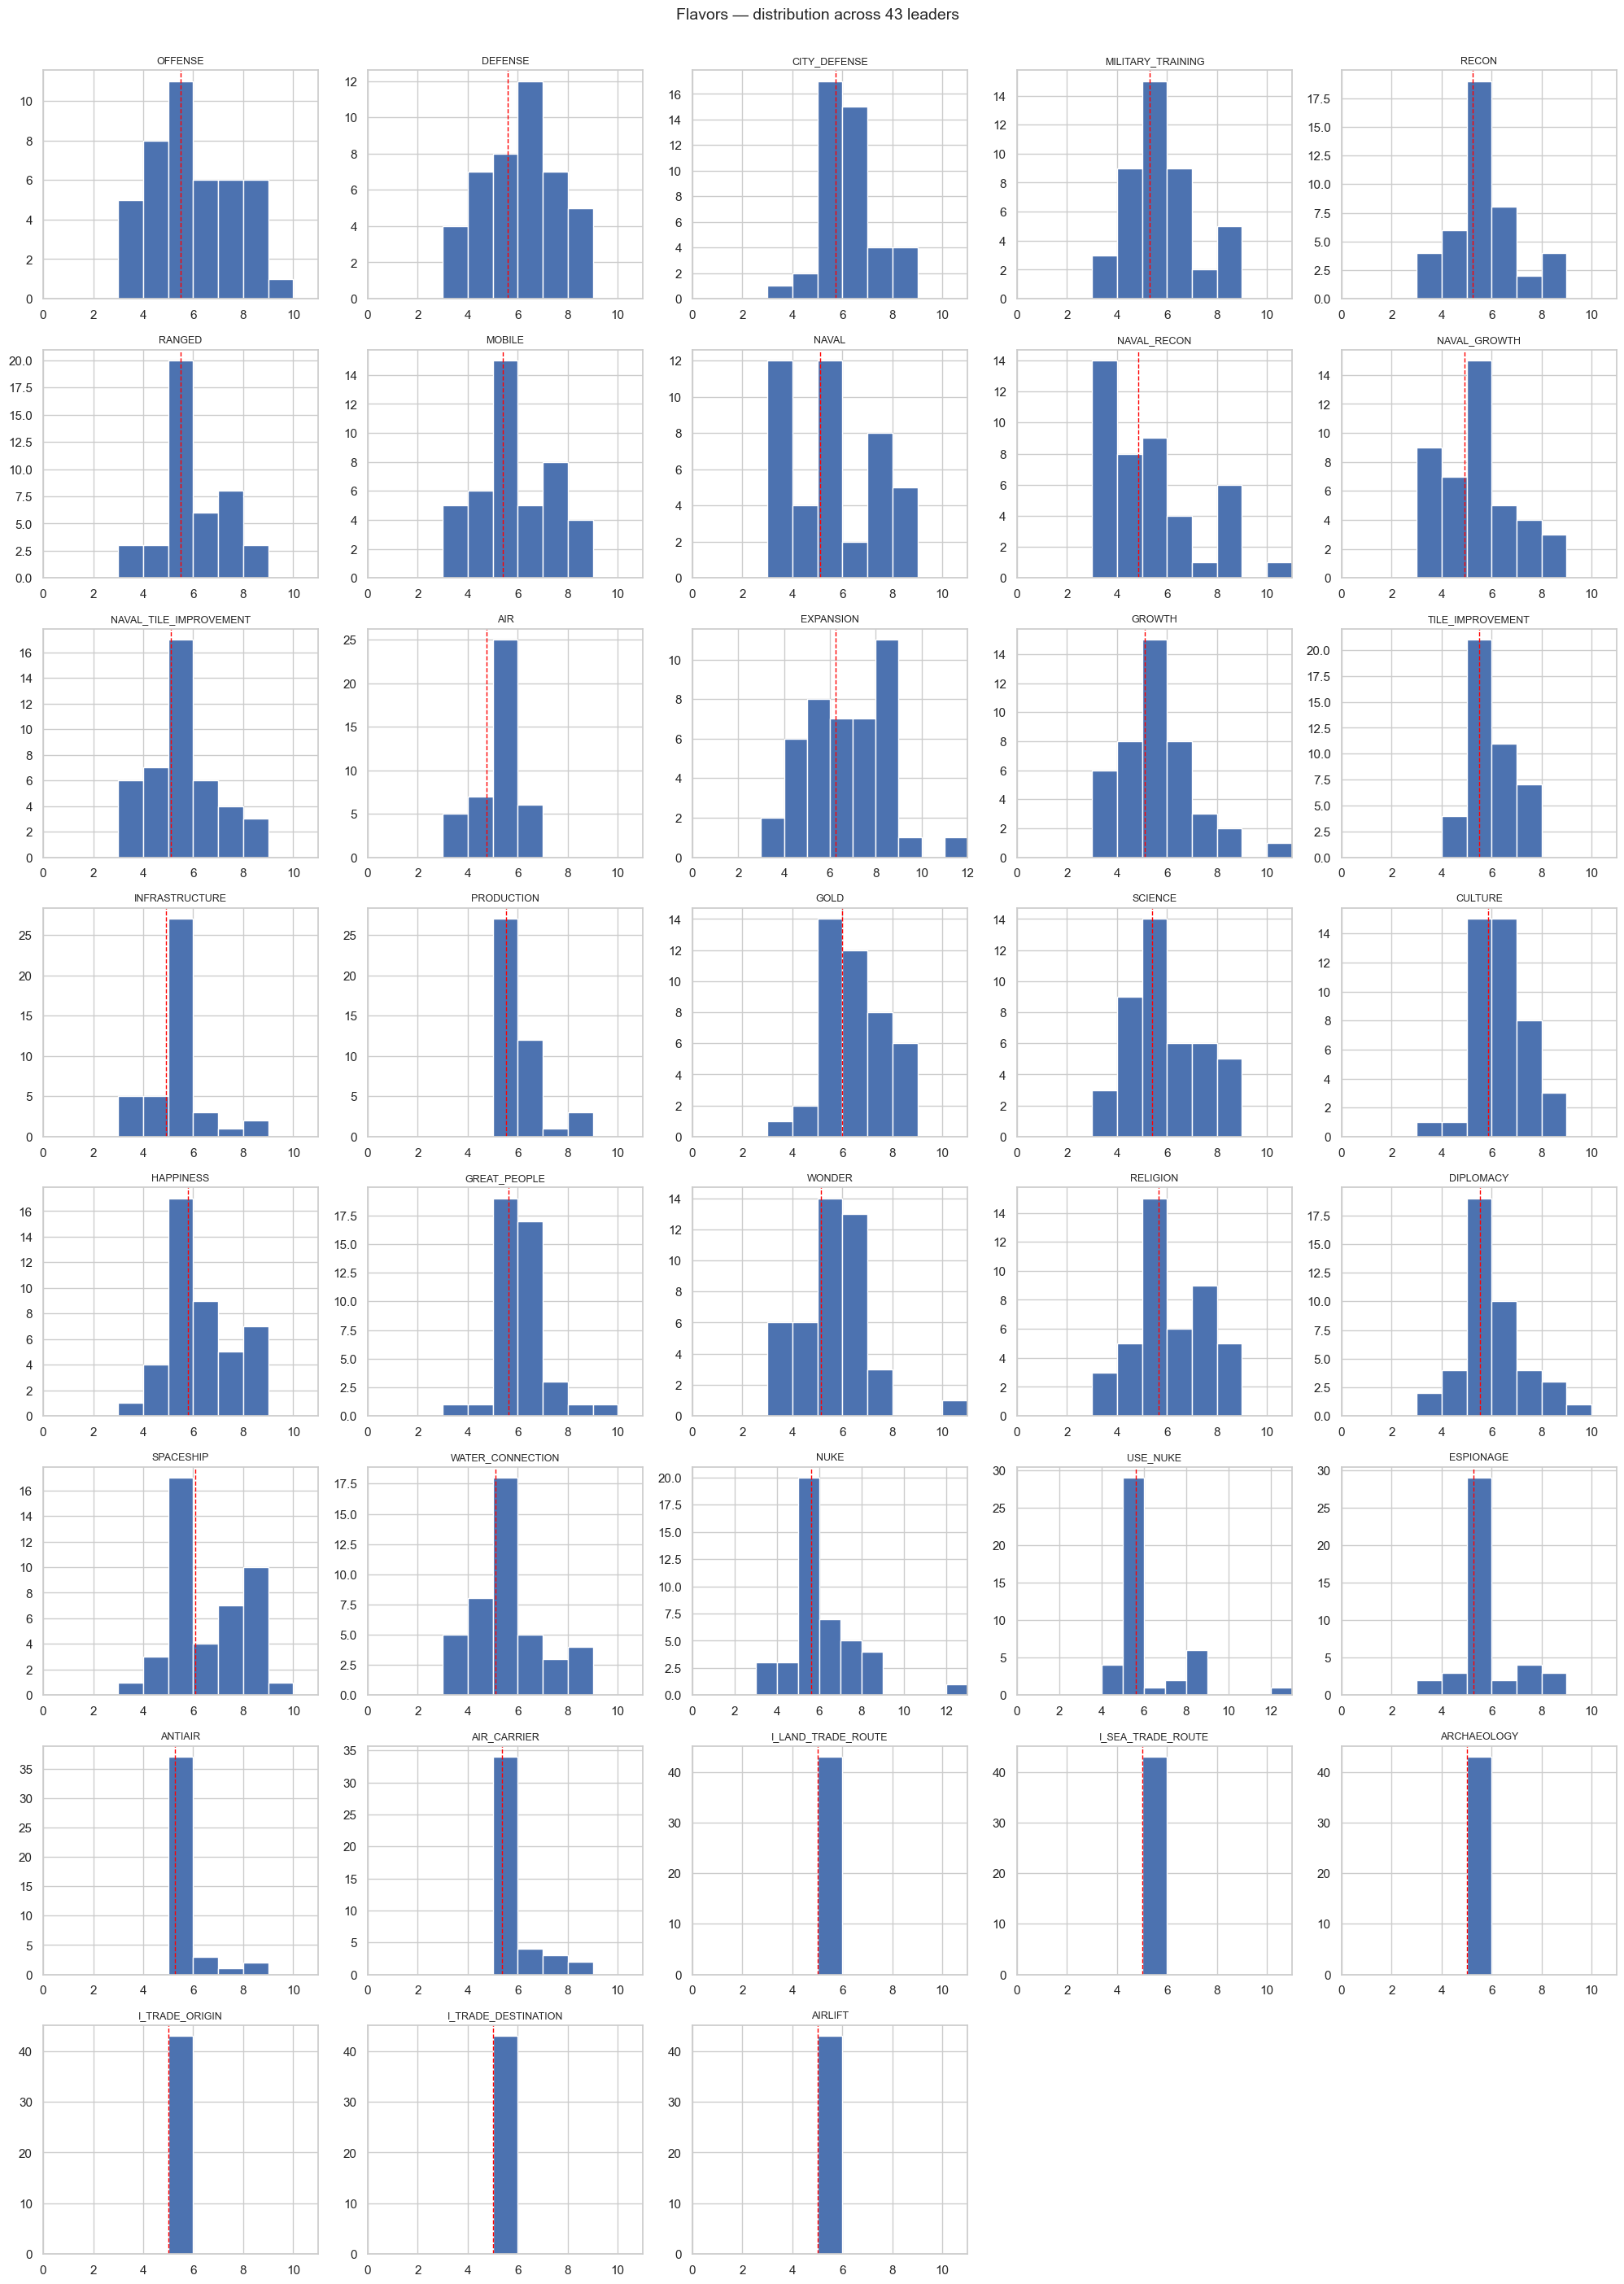

In [11]:
fig, axes = plt.subplots(8, 5, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(flavors):
    max_val = max(10, df[col].max())
    axes[i].hist(df[col], bins=range(0, int(max_val) + 2), edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlim(0, max_val + 1)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1)

for j in range(len(flavors), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Flavors — distribution across 43 leaders", fontsize=14, y=1.002)
plt.tight_layout()
plt.show()

Flavors summary statistics + verifications

In [12]:
summary = df[flavors].describe().T[["mean", "std", "min", "max"]]
summary["range"] = summary["max"] - summary["min"]
summary = summary.sort_values("std", ascending=False)
print(summary.round(2))

print("\nValues above 10:")
for col in flavors:
    mask = df[col] > 10
    if mask.any():
        print(df[["leader_name", col]][mask].to_string(index=False))

print("\nTop 5 — EXPANSION:")
print(df[["leader_name", "EXPANSION"]].sort_values("EXPANSION", ascending=False).head(5).to_string(index=False))

                        mean   std  min   max  range
NAVAL_RECON             4.84  1.89  3.0  10.0    7.0
EXPANSION               6.26  1.77  3.0  11.0    8.0
NAVAL                   5.12  1.76  3.0   8.0    5.0
OFFENSE                 5.51  1.67  3.0   9.0    6.0
NUKE                    5.63  1.62  3.0  12.0    9.0
USE_NUKE                5.60  1.55  4.0  12.0    8.0
GROWTH                  5.12  1.50  3.0  10.0    7.0
SPACESHIP               6.09  1.49  3.0   9.0    6.0
MOBILE                  5.40  1.48  3.0   8.0    5.0
DEFENSE                 5.60  1.48  3.0   8.0    5.0
NAVAL_GROWTH            4.93  1.47  3.0   8.0    5.0
SCIENCE                 5.42  1.45  3.0   8.0    5.0
RELIGION                5.65  1.43  3.0   8.0    5.0
WATER_CONNECTION        5.12  1.38  3.0   8.0    5.0
NAVAL_TILE_IMPROVEMENT  5.09  1.38  3.0   8.0    5.0
WONDER                  5.14  1.37  3.0  10.0    7.0
MILITARY_TRAINING       5.30  1.37  3.0   8.0    5.0
HAPPINESS               5.79  1.32  3.0   8.0 

Correlation matrices

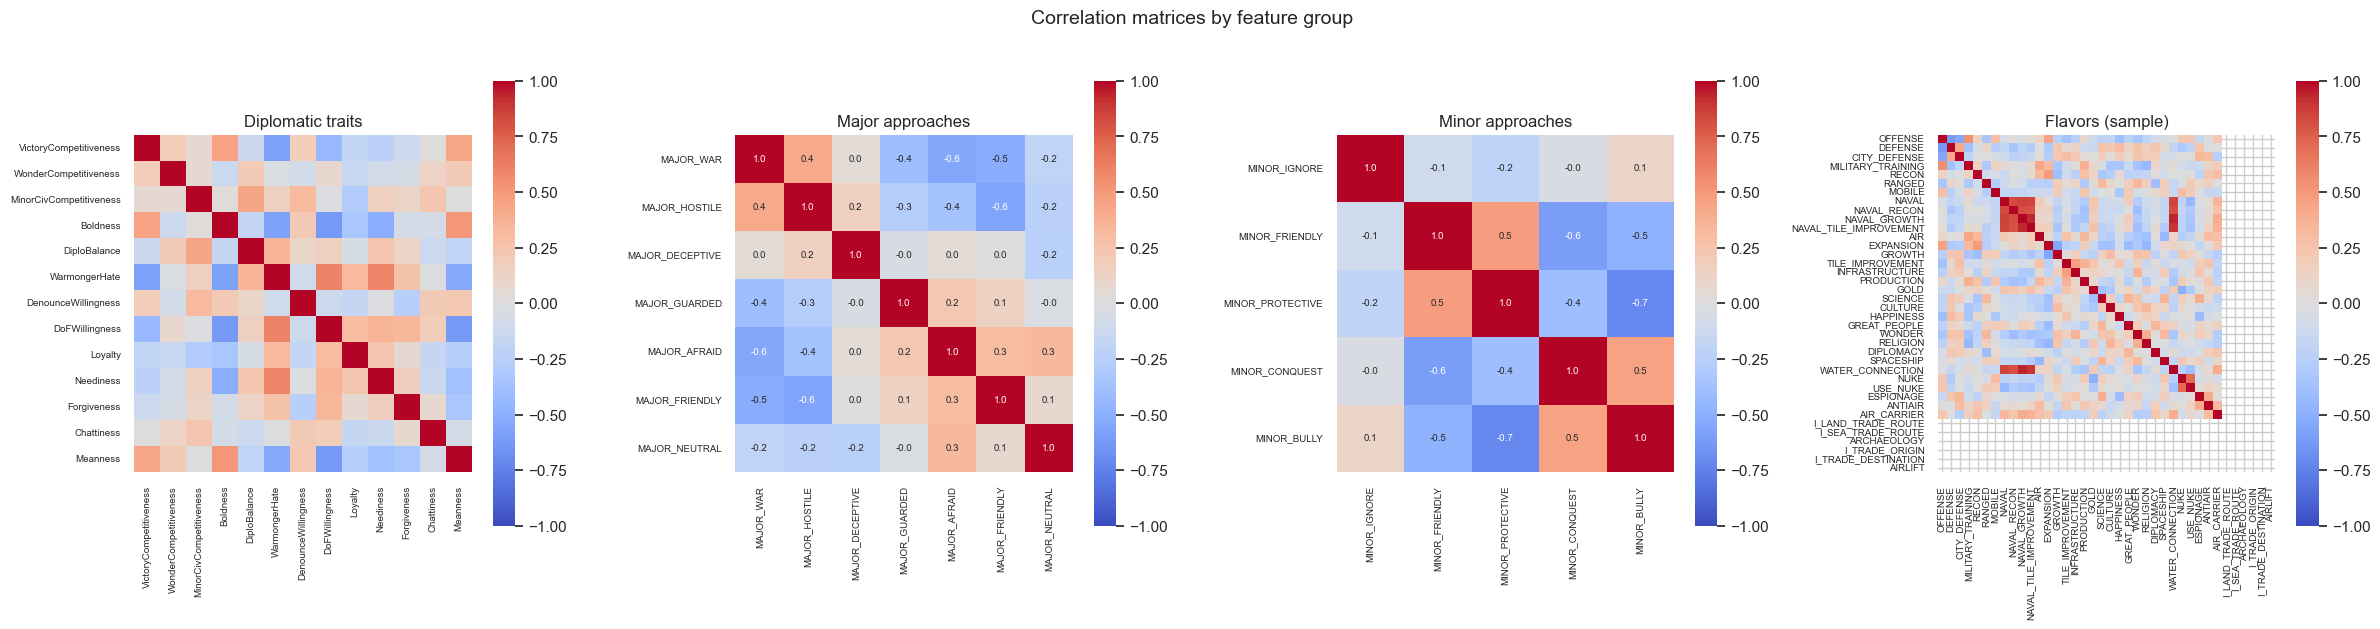

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

feature_groups = {
    "Diplomatic traits": diplo_traits,
    "Major approaches": major_approaches,
    "Minor approaches": minor_approaches,
    "Flavors (sample)": flavors
}

for ax, (title, cols) in zip(axes, feature_groups.items()):
    corr = df[cols].corr()
    sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=True, yticklabels=True,
                annot=len(cols) <= 10, fmt=".1f", annot_kws={"size": 7})
    ax.set_title(title, fontsize=12)
    ax.tick_params(labelsize=7)

plt.suptitle("Correlation matrices by feature group", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../figures/correlation_matrices.png", dpi=150, bbox_inches="tight")
plt.show()